In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

pd.set_option('display.max_columns', None)

sns.set_theme(style="whitegrid")

In [2]:
from google.colab import files

uploaded = files.upload()

Saving dataset.csv to dataset.csv


In [3]:
file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 4000
Columns: 28


In [4]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


In [7]:
print("Total missing values:", df.isnull().sum().sum())
print("Total duplicate rows:", df.duplicated().sum())

Total missing values: 120
Total duplicate rows: 0


In [8]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [9]:
df = df.drop_duplicates()

print("Rows after removing duplicates:", len(df))

Rows after removing duplicates: 4000


In [10]:
print(df['Season'].value_counts())

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


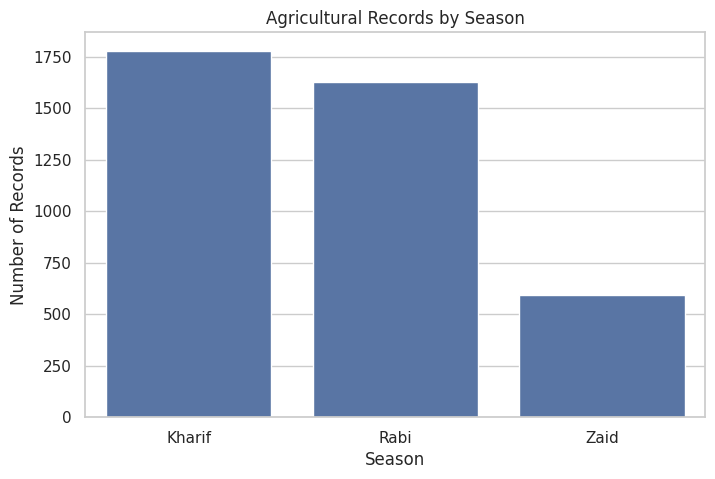

In [11]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='Season')

plt.title('Agricultural Records by Season')
plt.xlabel('Season')
plt.ylabel('Number of Records')

plt.show()

In [12]:
season_summary = df.groupby('Season').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'mean',
    'Total_Cost_INR': 'mean',
    'Revenue_INR': 'mean',
    'Profit_INR': 'mean',
    'Water_Used_m3': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean'
}).round(2)

season_summary

,Yield_Tonnes_Ha,Production_Tonnes,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3
Season,,,,,,,
Kharif,5.64,46.31,531804.41,710719.06,178914.65,6102.20,5.89
Rabi,5.08,41.49,513836.58,601526.05,87689.47,5846.99,5.19
Zaid,4.67,38.89,543976.73,519171.90,-24804.82,6419.89,4.41


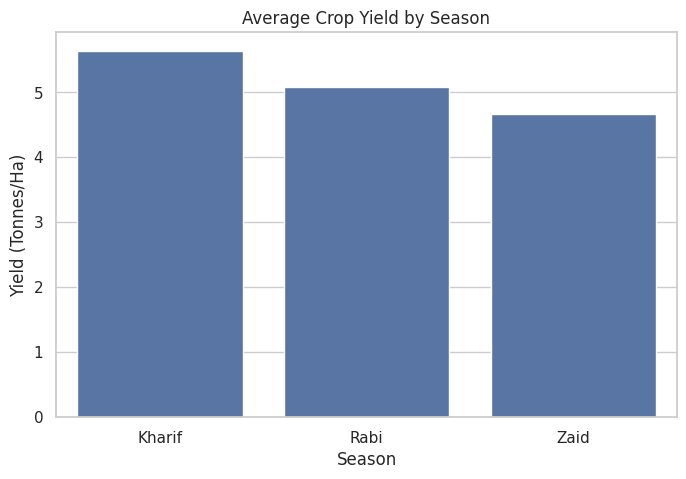

In [13]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Season',
    y='Yield_Tonnes_Ha',
    errorbar=None
)

plt.title('Average Crop Yield by Season')
plt.xlabel('Season')
plt.ylabel('Yield (Tonnes/Ha)')

plt.show()

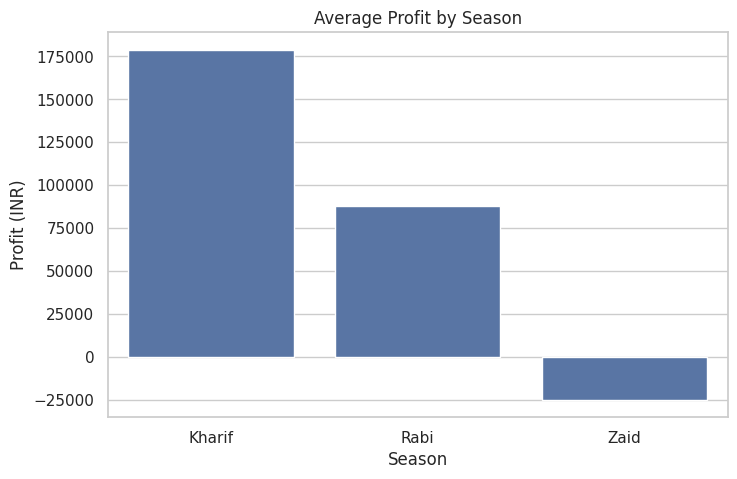

In [14]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Season',
    y='Profit_INR',
    errorbar=None
)

plt.title('Average Profit by Season')
plt.xlabel('Season')
plt.ylabel('Profit (INR)')

plt.show()

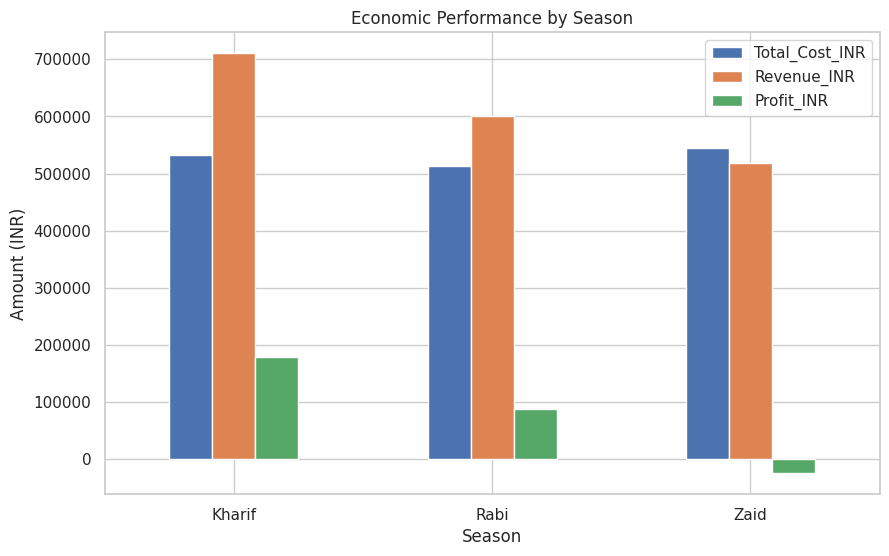

In [15]:
economic_data = df.groupby('Season')[[
    'Total_Cost_INR',
    'Revenue_INR',
    'Profit_INR'
]].mean()

economic_data.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Economic Performance by Season')
plt.xlabel('Season')
plt.ylabel('Amount (INR)')
plt.xticks(rotation=0)

plt.show()

In [16]:
environment_summary = df.groupby('Season').agg({
    'Rainfall_mm': 'mean',
    'Avg_Temperature_C': 'mean',
    'Humidity_pct': 'mean',
    'Sunlight_Hours_Day': 'mean',
    'Soil_pH': 'mean',
    'Soil_Moisture_pct': 'mean'
}).round(2)

environment_summary

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct
Season,,,,,,
Kharif,852.08,28.45,71.81,6.79,6.73,31.20
Rabi,436.00,23.49,57.89,7.59,6.67,24.05
Zaid,299.42,31.04,52.01,8.18,6.69,19.17


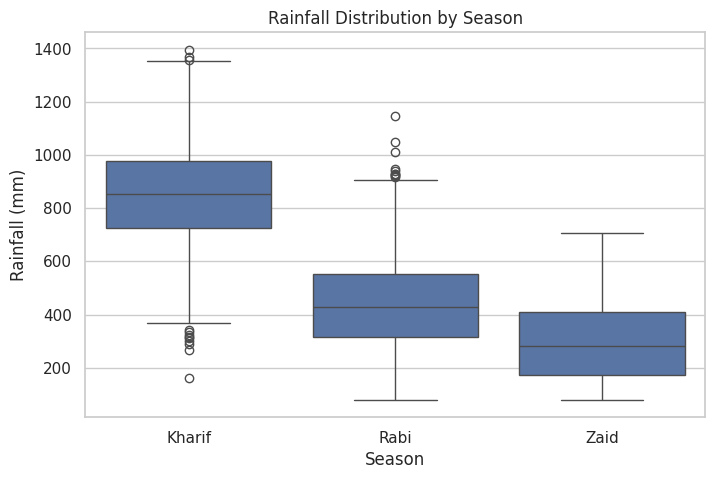

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Season',
    y='Rainfall_mm'
)

plt.title('Rainfall Distribution by Season')
plt.xlabel('Season')
plt.ylabel('Rainfall (mm)')

plt.show()

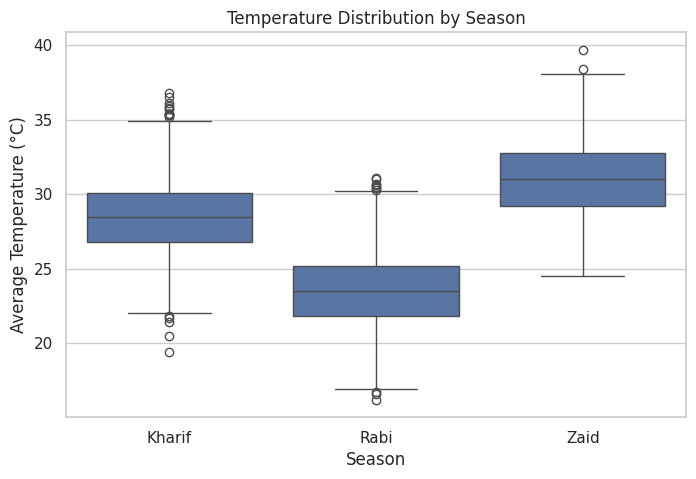

In [18]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Season',
    y='Avg_Temperature_C'
)

plt.title('Temperature Distribution by Season')
plt.xlabel('Season')
plt.ylabel('Average Temperature (°C)')

plt.show()

In [19]:
resource_summary = df.groupby('Season').agg({
    'Nitrogen_kg_ha': 'mean',
    'Phosphorus_kg_ha': 'mean',
    'Potassium_kg_ha': 'mean',
    'Fertilizer_kg_ha': 'mean',
    'Pesticide_Litre_ha': 'mean',
    'Water_Used_m3': 'mean'
}).round(2)

resource_summary

,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Used_m3
Season,,,,,,
Kharif,120.02,58.10,105.30,187.08,5.08,6102.20
Rabi,120.40,57.31,103.93,185.41,5.02,5846.99
Zaid,120.53,58.13,105.42,184.64,5.17,6419.89


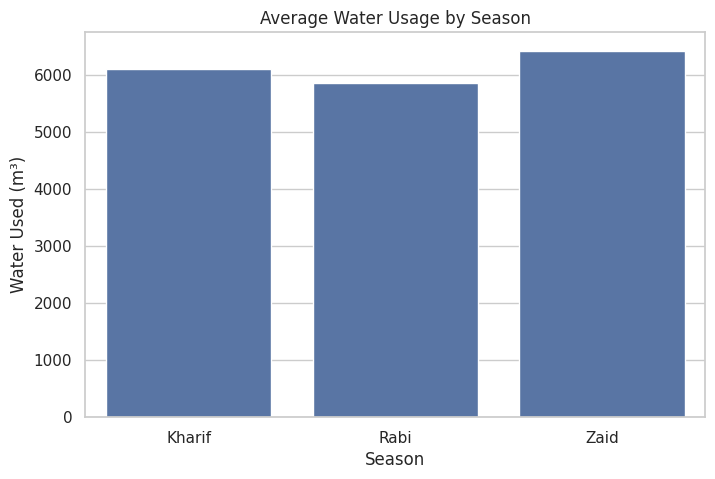

In [20]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Season',
    y='Water_Used_m3',
    errorbar=None
)

plt.title('Average Water Usage by Season')
plt.xlabel('Season')
plt.ylabel('Water Used (m³)')

plt.show()

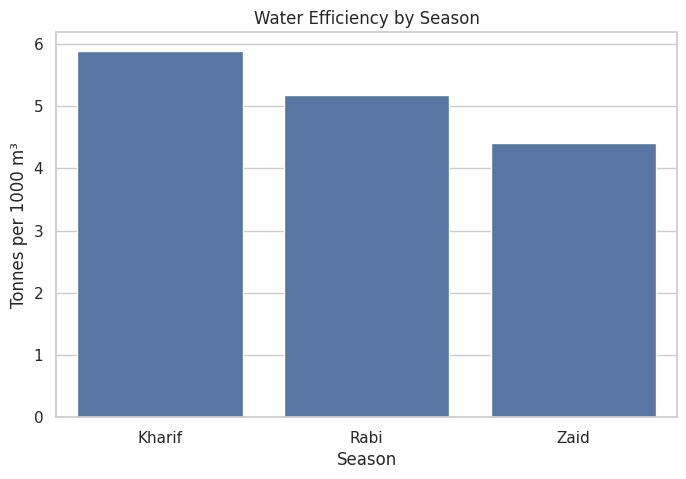

In [21]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Season',
    y='Water_Efficiency_t_per_1000m3',
    errorbar=None
)

plt.title('Water Efficiency by Season')
plt.xlabel('Season')
plt.ylabel('Tonnes per 1000 m³')

plt.show()

In [22]:
crop_summary = df.groupby('Crop').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'mean',
    'Revenue_INR': 'mean',
    'Profit_INR': 'mean'
}).sort_values(
    'Yield_Tonnes_Ha',
    ascending=False
).round(2)

crop_summary

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR
Crop,,,,
Sugarcane,46.94,392.41,1371980.11,817187.99
Maize,2.72,21.78,457067.99,-83978.33
Rice,2.44,19.29,423615.26,-102213.50
Wheat,2.11,16.85,400104.89,-123398.34
Chilli,1.54,12.38,1276777.23,750878.34
Groundnut,1.32,9.66,542935.50,44858.12
Cotton,1.23,9.40,639423.08,124546.92
Pulses,0.92,7.40,528465.87,-4238.05


In [23]:
crop_season = df.groupby(
    ['Crop', 'Season']
)['Yield_Tonnes_Ha'].mean().reset_index()

crop_season

,Crop,Season,Yield_Tonnes_Ha
0,Chilli,Kharif,1.731413
1,Chilli,Rabi,1.461615
2,Chilli,Zaid,1.177742
3,Cotton,Kharif,1.372804
4,Cotton,Rabi,1.192915
5,Cotton,Zaid,0.951648
6,Groundnut,Kharif,1.483646
7,Groundnut,Rabi,1.221445
8,Groundnut,Zaid,1.037778
9,Maize,Kharif,2.966410


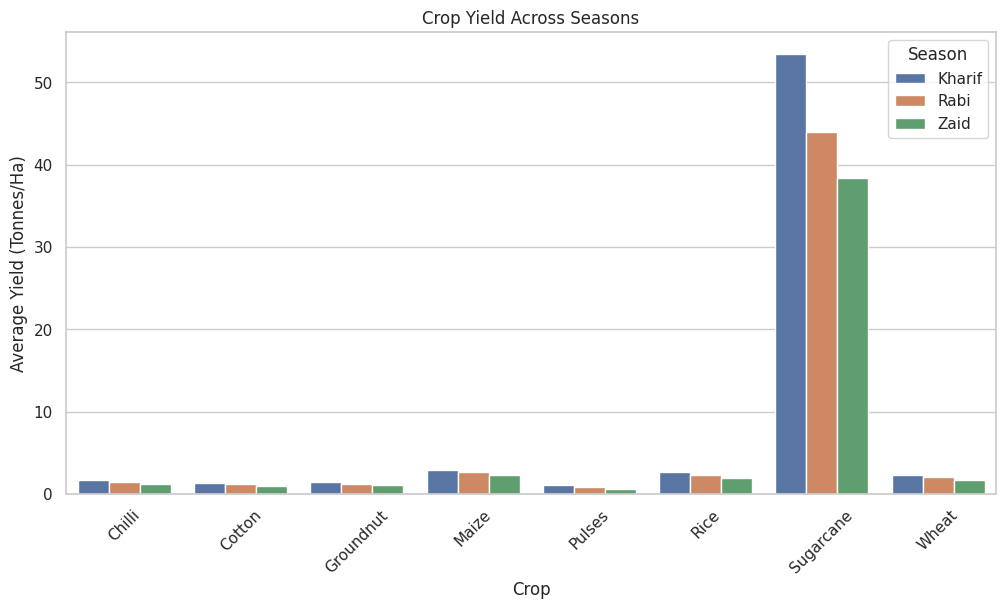

In [24]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=crop_season,
    x='Crop',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title('Crop Yield Across Seasons')
plt.xlabel('Crop')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.xticks(rotation=45)

plt.show()

In [25]:
state_season = df.pivot_table(
    index='State',
    columns='Season',
    values='Yield_Tonnes_Ha',
    aggfunc='mean'
)

state_season.round(2)

Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,5.69,3.49,4.48
Gujarat,6.34,5.52,4.10
Karnataka,6.52,4.61,6.62
Madhya Pradesh,6.00,3.80,5.54
Maharashtra,5.45,5.50,2.29
Punjab,4.10,8.61,5.91
Tamil Nadu,5.52,4.56,4.10
Telangana,5.57,4.83,4.28


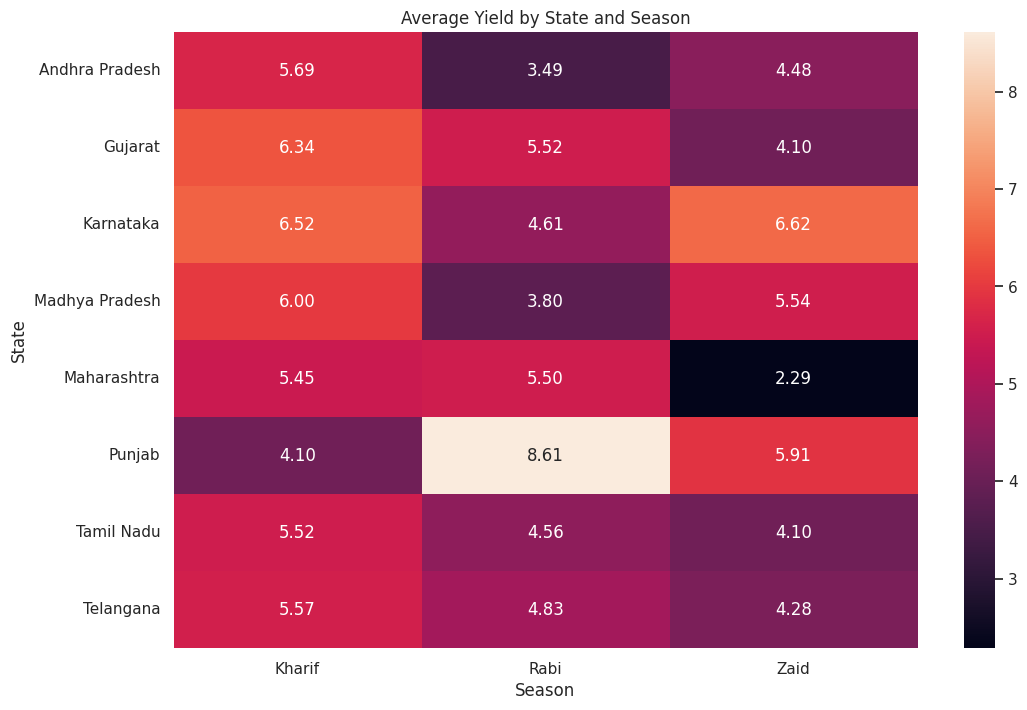

In [26]:
plt.figure(figsize=(12,8))

sns.heatmap(
    state_season,
    annot=True,
    fmt='.2f'
)

plt.title('Average Yield by State and Season')
plt.xlabel('Season')
plt.ylabel('State')

plt.show()

In [27]:
irrigation_summary = df.groupby('Irrigation_Method').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Water_Used_m3': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean',
    'Profit_INR': 'mean'
}).round(2)

irrigation_summary

,Yield_Tonnes_Ha,Water_Used_m3,Water_Efficiency_t_per_1000m3,Profit_INR
Irrigation_Method,,,,
Drip,6.62,5918.75,6.27,219626.00
Flood,4.90,8026.47,3.44,73354.02
Rainfed,4.61,3549.55,7.56,79050.37
Sprinkler,5.19,6208.26,4.67,91121.08


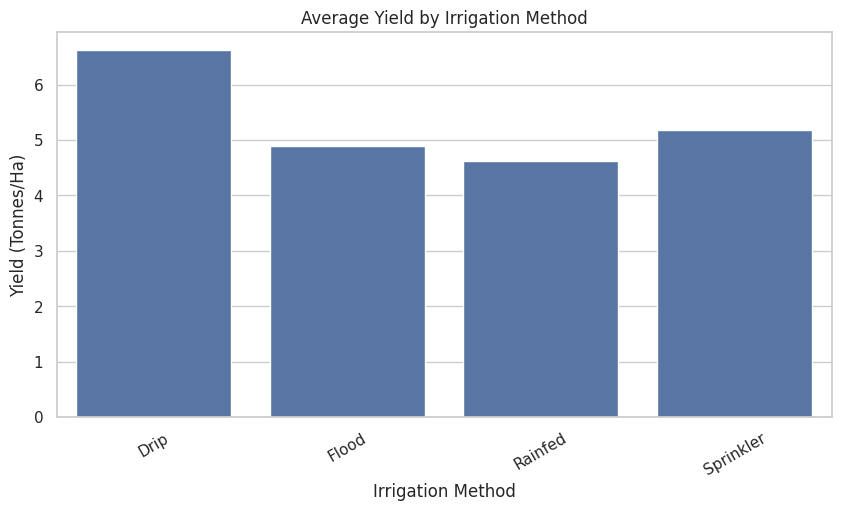

In [28]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x='Irrigation_Method',
    y='Yield_Tonnes_Ha',
    errorbar=None
)

plt.title('Average Yield by Irrigation Method')
plt.xlabel('Irrigation Method')
plt.ylabel('Yield (Tonnes/Ha)')

plt.xticks(rotation=30)

plt.show()

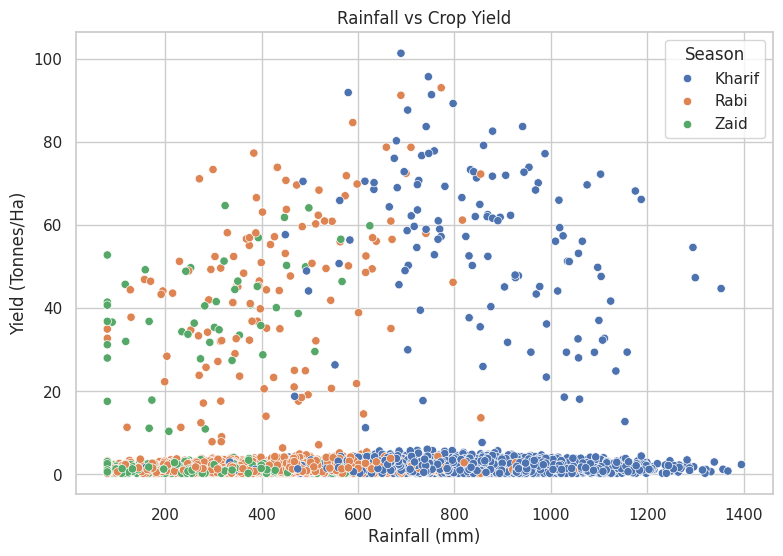

In [29]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x='Rainfall_mm',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title('Rainfall vs Crop Yield')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes/Ha)')

plt.show()

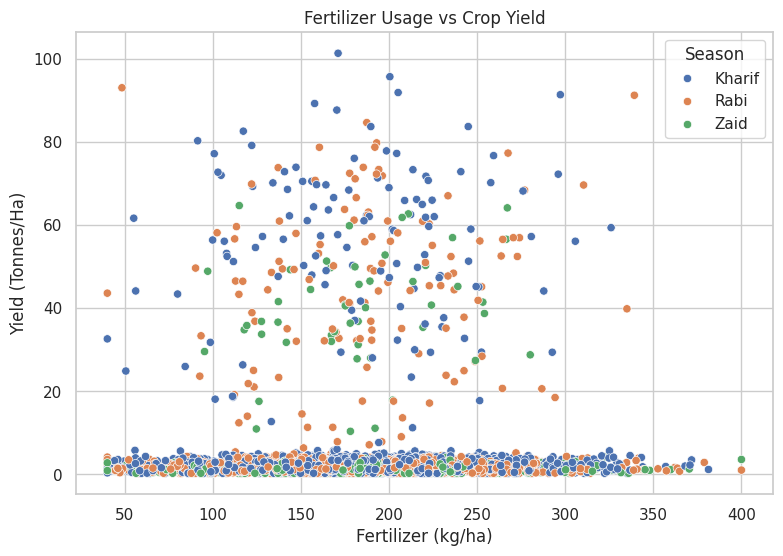

In [30]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x='Fertilizer_kg_ha',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title('Fertilizer Usage vs Crop Yield')
plt.xlabel('Fertilizer (kg/ha)')
plt.ylabel('Yield (Tonnes/Ha)')

plt.show()

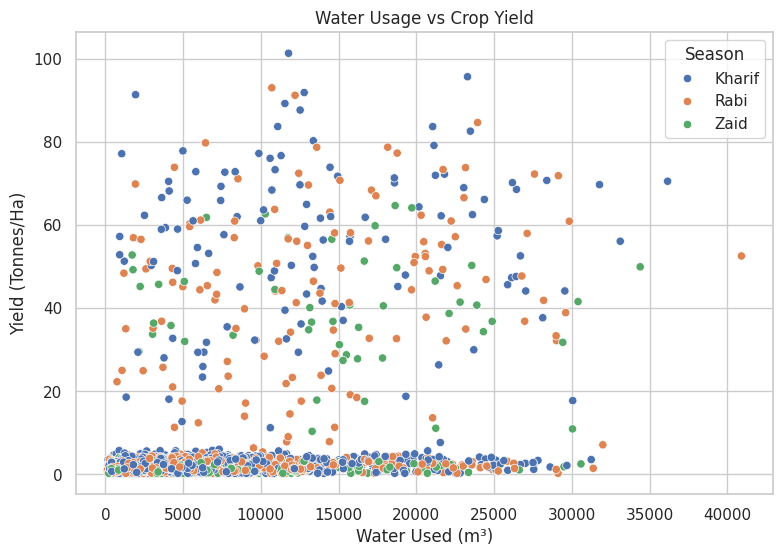

In [31]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x='Water_Used_m3',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title('Water Usage vs Crop Yield')
plt.xlabel('Water Used (m³)')
plt.ylabel('Yield (Tonnes/Ha)')

plt.show()

In [33]:
numeric_columns = df.select_dtypes(include=np.number)

yield_correlation = numeric_columns.corr()['Yield_Tonnes_Ha'].sort_values(
    ascending=False
)

yield_correlation.round(3)

,Yield_Tonnes_Ha
Yield_Tonnes_Ha,1.000
Water_Efficiency_t_per_1000m3,0.915
Production_Tonnes,0.885
Profit_INR,0.490
Revenue_INR,0.434
Water_Used_m3,0.389
Nitrogen_kg_ha,0.054
Phosphorus_kg_ha,0.048
Rainfall_mm,0.031
Total_Cost_INR,0.031


In [44]:

numeric_columns = df.select_dtypes(include='number')

yield_correlation = (
    numeric_columns
    .corr()['Yield_Tonnes_Ha']
    .sort_values(ascending=False)
)

print("Correlation of Variables with Crop Yield:")
print(yield_correlation.round(3))

Correlation of Variables with Crop Yield:
Yield_Tonnes_Ha                  1.000
Water_Efficiency_t_per_1000m3    0.915
Production_Tonnes                0.885
Profit_INR                       0.490
Revenue_INR                      0.434
Water_Used_m3                    0.389
Nitrogen_kg_ha                   0.054
Phosphorus_kg_ha                 0.048
Rainfall_mm                      0.031
Total_Cost_INR                   0.031
Farm_Area_Hectares               0.030
Disease_Pest_Risk_pct            0.013
Humidity_pct                     0.011
Soil_Moisture_pct                0.010
Avg_Temperature_C                0.009
Potassium_kg_ha                  0.004
Fertilizer_kg_ha                 0.001
Seed_Quality_Score              -0.007
Pesticide_Litre_ha              -0.008
Sunlight_Hours_Day              -0.015
Soil_pH                         -0.021
Market_Price_INR_Tonne          -0.384
Name: Yield_Tonnes_Ha, dtype: float64


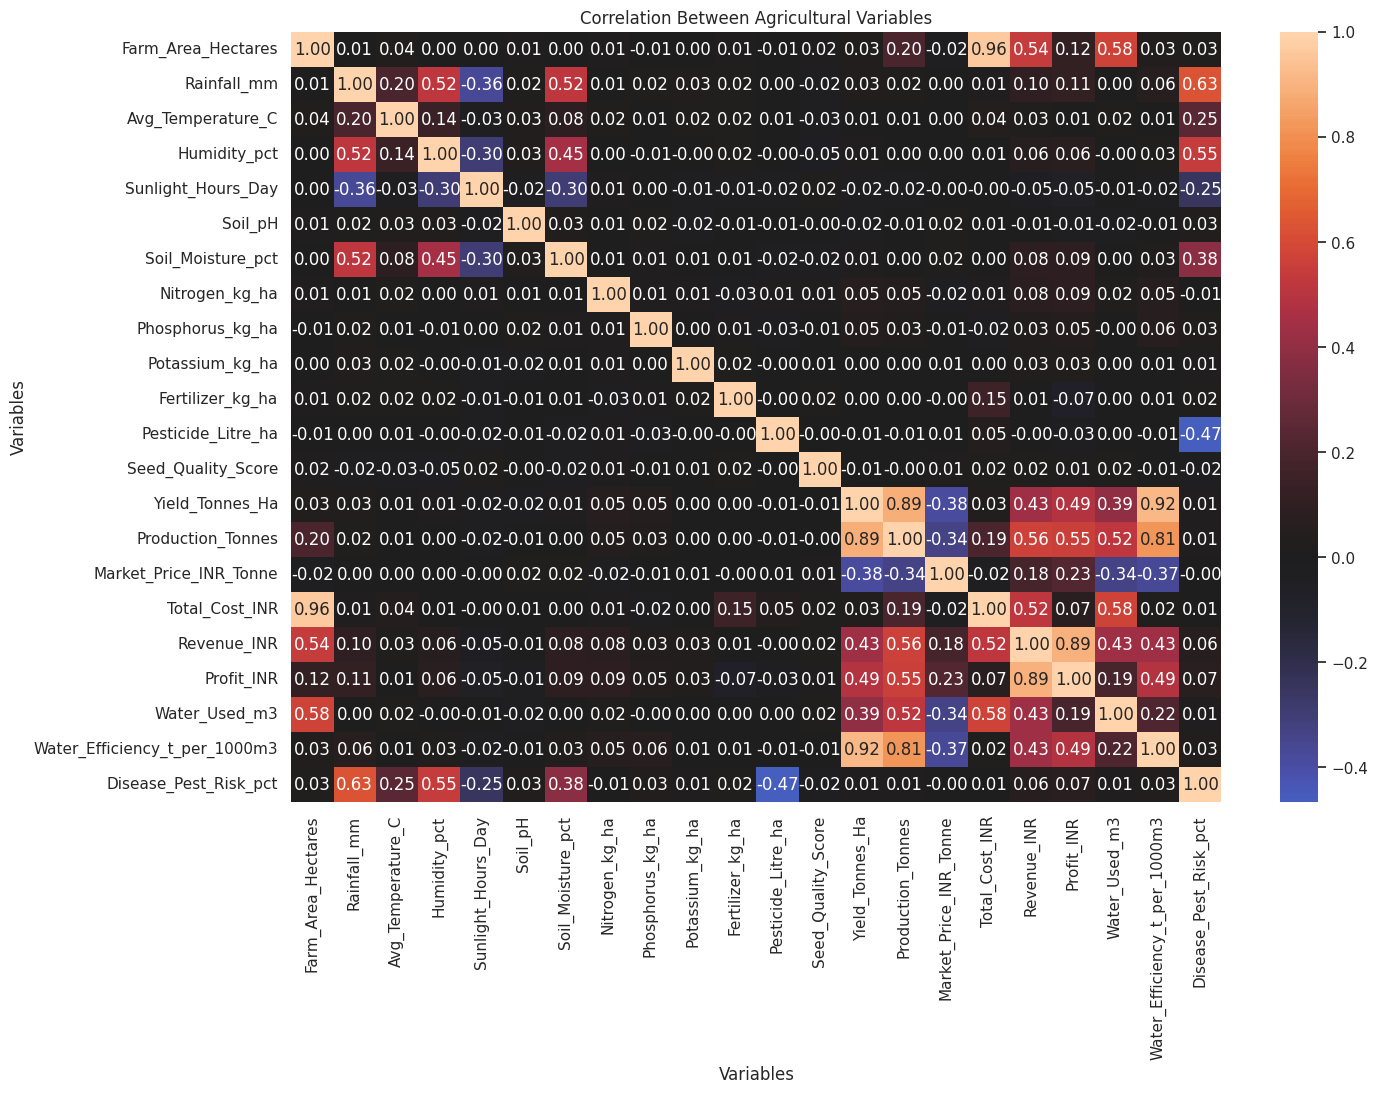

In [43]:


numeric_columns = df.select_dtypes(include='number')


correlation_matrix = numeric_columns.corr()


plt.figure(figsize=(15, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    center=0
)

plt.title('Correlation Between Agricultural Variables')
plt.xlabel('Variables')
plt.ylabel('Variables')

plt.show()

In [34]:
risk_summary = df.groupby('Season')[
    'Disease_Pest_Risk_pct'
].mean().round(2)

risk_summary

,Disease_Pest_Risk_pct
Season,
Kharif,54.47
Rabi,40.48
Zaid,38.22


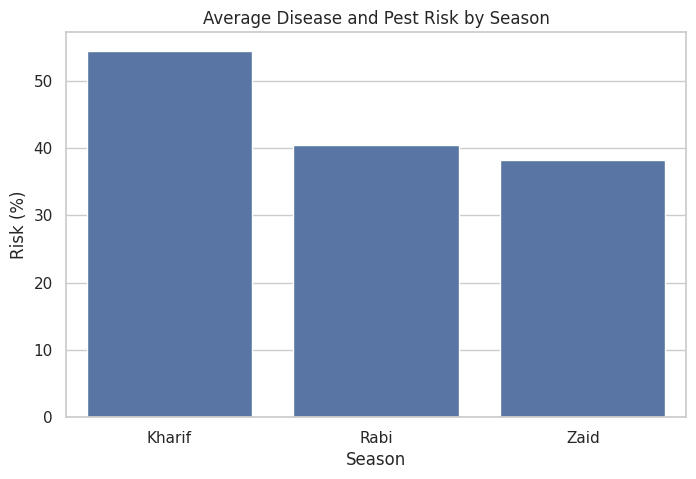

In [35]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Season',
    y='Disease_Pest_Risk_pct',
    errorbar=None
)

plt.title('Average Disease and Pest Risk by Season')
plt.xlabel('Season')
plt.ylabel('Risk (%)')

plt.show()

In [36]:
season_groups = [
    group['Yield_Tonnes_Ha'].dropna()
    for _, group in df.groupby('Season')
]

anova_result = stats.f_oneway(*season_groups)

print("F-statistic:", round(anova_result.statistic, 4))
print("P-value:", round(anova_result.pvalue, 6))

F-statistic: 1.458
P-value: 0.232835


In [37]:
if anova_result.pvalue < 0.05:
    print("There is a statistically significant difference in average yield between seasons.")
else:
    print("There is no statistically significant difference in average yield between seasons.")

There is no statistically significant difference in average yield between seasons.


In [38]:
final_summary = df.groupby('Season').agg(
    Average_Yield=('Yield_Tonnes_Ha', 'mean'),
    Average_Production=('Production_Tonnes', 'mean'),
    Average_Water_Usage=('Water_Used_m3', 'mean'),
    Average_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean'),
    Average_Revenue=('Revenue_INR', 'mean'),
    Average_Cost=('Total_Cost_INR', 'mean'),
    Average_Profit=('Profit_INR', 'mean')
).round(2)

final_summary

,Average_Yield,Average_Production,Average_Water_Usage,Average_Water_Efficiency,Average_Revenue,Average_Cost,Average_Profit
Season,,,,,,,
Kharif,5.64,46.31,6102.20,5.89,710719.06,531804.41,178914.65
Rabi,5.08,41.49,5846.99,5.19,601526.05,513836.58,87689.47
Zaid,4.67,38.89,6419.89,4.41,519171.90,543976.73,-24804.82


In [39]:
print("Highest Average Yield:")
print(final_summary['Average_Yield'].idxmax())

print("\nHighest Average Profit:")
print(final_summary['Average_Profit'].idxmax())

print("\nHighest Water Efficiency:")
print(final_summary['Average_Water_Efficiency'].idxmax())

print("\nHighest Average Revenue:")
print(final_summary['Average_Revenue'].idxmax())

Highest Average Yield:
Kharif

Highest Average Profit:
Kharif

Highest Water Efficiency:
Kharif

Highest Average Revenue:
Kharif


In [40]:
top_crops = df.groupby('Crop').agg(
    Average_Yield=('Yield_Tonnes_Ha', 'mean'),
    Average_Profit=('Profit_INR', 'mean')
).sort_values(
    'Average_Yield',
    ascending=False
).round(2)

top_crops

,Average_Yield,Average_Profit
Crop,,
Sugarcane,46.94,817187.99
Maize,2.72,-83978.33
Rice,2.44,-102213.50
Wheat,2.11,-123398.34
Chilli,1.54,750878.34
Groundnut,1.32,44858.12
Cotton,1.23,124546.92
Pulses,0.92,-4238.05


In [45]:
print("Final Dataset")
print("-------------------------")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())

Final Dataset
-------------------------
Rows: 4000
Columns: 28
Missing Values: 120
Duplicate Rows: 0


In [46]:
df.to_csv(
    'cleaned_seasonal_agriculture_dataset.csv',
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.
